Name : Manmath Maroti Kornule

PRN : 202401110045

# Employee Attrition Prediction — Feature Engineering
**Dataset:** Kaggle Employee Attrition Dataset (10,000 rows)

**Objective:** Apply feature engineering techniques to prepare the data for machine learning models.


**Step 1:**

We load the Employee Attrition dataset into a Pandas DataFrame and view the first few records to understand its structure.
This helps us identify the types of data (numeric/categorical) and any irregularities.

In [18]:
# Importing essential libraries

import pandas as pd   # For data handling
import numpy as np    # For numerical computations

# Loading the dataset
df = pd.read_csv('employee_attrition_dataset.csv')

# Displaying first 5 rows to get an overview
df.head()


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5.0,7332,81,24.0,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4.0,6069,55,18.0,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4.0,11485,65,6.0,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4.0,18707,28,12.0,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1.0,16398,92,3.0,...,No,1,54,11,1,1,1,43,4,No


**Step 2 :**

Before performing any preprocessing, we need to check whether our dataset contains missing (null) values.
Missing values can lead to incorrect model training, so we’ll inspect how many are present in each column.

In [19]:
# Checking for missing (null) values in the dataset

# The isnull() method identifies missing values as True, and sum() counts them per column
df.isnull().sum()


,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,12
Job_Role,27
Job_Level,1
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,1


**Step 3 :**

Before imputing missing numeric values, we check if their distributions are symmetric or skewed.
If a feature’s data is symmetric (skewness near 0), we can safely fill missing values with the mean.
If it’s skewed (skewness far from 0), we should use the median, which is less affected by outliers.

In [20]:
# Checking skewness for numeric columns with missing values
numeric_cols = ['Job_Level', 'Years_at_Company', 'Years_in_Current_Role', 'Job_Satisfaction']

# Calculate skewness for each column
df[numeric_cols].skew()


,0
Job_Level,0.015364
Years_at_Company,0.025687
Years_in_Current_Role,0.003512
Job_Satisfaction,-0.034426


**Conclusion**:
All the numeric columns with missing values are nearly symmetric (skewness very close to 0), so filling missing values with **mean** is correct.and catogarical colums are filled with mode.

**Step 4 :**

We handle missing data based on the type of feature:

- Categorical columns (e.g., Department, Job_Role, Overtime) are filled using the most frequent (mode) value.

- Numerical columns (e.g., Job_Level, Years_at_Company, Years_in_Current_Role, Job_Satisfaction) are filled using the mean.

- This approach maintains the overall data distribution while removing missing entries.

In [21]:
# Handling missing values (future-proof method)

# Fill categorical columns with mode
categorical_cols = ['Department', 'Job_Role', 'Overtime']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns with mean
numerical_cols = ['Job_Level', 'Years_at_Company', 'Years_in_Current_Role', 'Job_Satisfaction']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Verify that missing values are handled
df.isnull().sum()


,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


**Step 5 :**

Machine learning models cannot work directly with text/categorical data.
We need to convert these features into numeric form:

- Label Encoding → Assigns each category a unique integer (useful for ordinal categories like Job_Level if present)

- One-Hot Encoding → Converts each category into a separate binary column (useful for nominal categories like Department, Gender, Marital_Status)

In this dataset, we will use One-Hot Encoding for nominal categorical columns.

Categorical columns to encode:
Gender, Marital_Status, Department, Job_Role, Overtime

In [22]:
# List of categorical columns to encode
categorical_cols = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']

# Perform One-Hot Encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display first 5 rows of the encoded dataset
df_encoded.head()


,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,1,58,5.0,7332,81,24.0,12.0,3,1,3.0,...,False,True,False,False,False,False,False,False,True,False
1,2,48,4.0,6069,55,18.0,7.0,5,1,2.0,...,False,False,True,False,False,False,True,False,False,True
2,3,34,4.0,11485,65,6.0,4.0,3,4,5.0,...,True,False,False,False,True,False,False,False,True,True
3,4,27,4.0,18707,28,12.0,9.0,1,1,1.0,...,False,False,True,False,False,False,False,False,True,False
4,5,40,1.0,16398,92,3.0,9.0,1,3,4.0,...,True,False,True,False,False,False,False,False,False,False


**Step 6 — Feature Scaling**

Machine learning models (especially distance-based or gradient-based) perform better if numeric features are on a similar scale.

We will scale all numeric columns (like Age, Years_at_Company, Monthly_Income, etc.) using Standardization (mean=0, std=1).

In [23]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column from scaling
numeric_cols = [col for col in numeric_cols if col != 'Attrition']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform numeric columns
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# Display first 5 rows after scaling
df_encoded.head()


,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,-1.731878,1.609703,1.424673,-0.833228,0.970273,1.074991,1.126343,-0.509049,-1.350724,-0.026734,...,False,True,False,False,False,False,False,False,True,False
1,-1.731531,0.736677,0.715669,-1.089608,-0.082273,0.363344,-0.111390,0.182641,-1.350724,-0.733705,...,False,False,True,False,False,False,True,False,False,True
2,-1.731185,-0.485560,0.715669,0.009801,0.322552,-1.059950,-0.854029,-0.509049,1.346409,1.387207,...,True,False,False,False,True,False,False,False,True,True
3,-1.730838,-1.096678,0.715669,1.475816,-1.175300,-0.348303,0.383703,-1.200738,-1.350724,-1.440675,...,False,False,True,False,False,False,False,False,True,False
4,-1.730492,0.038256,-1.411342,1.007105,1.415580,-1.415774,0.383703,-1.200738,0.447364,0.680236,...,True,False,True,False,False,False,False,False,False,False


**Step 7 — Feature Selection / Dimensionality Reduction**

Even with a clean and encoded dataset, some features may be redundant or contribute little to the model. Reducing unnecessary features can improve model performance, prevent overfitting, and make computations faster. Common approaches include correlation analysis, which removes highly correlated features, variance thresholding, which eliminates features with very low variance, and Principal Component Analysis (PCA), which transforms the dataset into a smaller set of components while retaining most of the original variance. These techniques help focus on the most informative features for modeling.

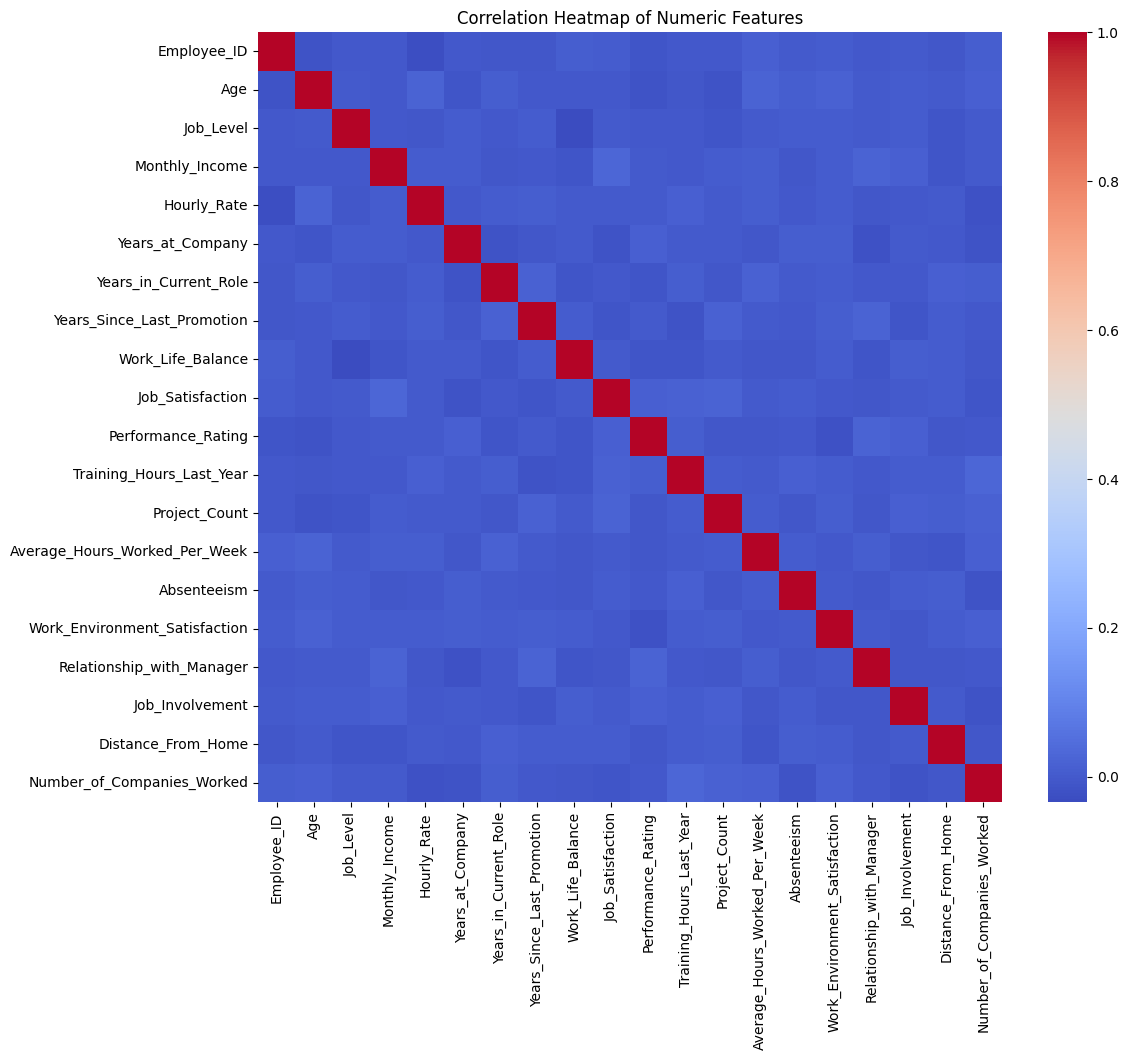

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df_encoded[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


**Step 8 — Principal Component Analysis (PCA)**

PCA is a technique that transforms the dataset into a smaller set of principal components while retaining most of the variance in the data.

- Helps reduce dimensionality, making the dataset easier to model.

- Can improve computation speed and reduce overfitting.

- Each component is a combination of original features.

We will apply PCA on the numeric features only, excluding the target column Attrition.

In [29]:
from sklearn.decomposition import PCA

# Selecting numeric features (excluding target)
features = df_encoded.drop(columns=['Attrition'])

# Initialize PCA to keep 95% variance
pca = PCA(n_components=0.95)

# Fit PCA on numeric features
pca_features = pca.fit_transform(features)

# Check the shape of the transformed data
print("Original numeric features shape:", features.shape)
print("Transformed features shape after PCA:", pca_features.shape)


Original numeric features shape: (10000, 31)
Transformed features shape after PCA: (10000, 24)


**Step 9 — Feature Selection using SelectKBest**

- SelectKBest selects features that have the strongest statistical relationship with the target.

- We chose top 10 features for demonstration.

- These features are the most informative predictors for the Attrition model.

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select numeric features (before PCA)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Apply SelectKBest to select top 10 features most correlated with Attrition
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

# Get the names of the selected features
selected_features = X.columns[selector.get_support(indices=True)].tolist()
print("Top 10 selected features:", selected_features)


Top 10 selected features: ['Employee_ID', 'Job_Level', 'Work_Life_Balance', 'Performance_Rating', 'Work_Environment_Satisfaction', 'Job_Involvement', 'Distance_From_Home', 'Marital_Status_Married', 'Job_Role_Assistant', 'Job_Role_Manager']
